# **Aula 4 - Implementação de Modelos Preditivos em Python**

- Modelos supervisionados: regressão linear, regressão logística, árvores de decisão, KNN.

- Pipeline de treinamento em scikit-learn (fit, predict, score).

- Comparação de modelos com métricas adequadas (R², MSE, Accuracy, Precision, Recall, F1).

Na aula de hoje, iremos aprender mais sobre os modelos de **machine learning**.

Veremos mais sobre os modelos de aprendizado supervisionado e lá, vimos que há basicamente 2 tarefas:
- Regressão
- Classificação

A *classificação* é uma típica tarefa de aprendizado de máquina supervisionado. O filtro de spam é um bom exemplo: ele é treinado com muitos exemplos de e-mails junto às classes (spam ou ham) e deve aprender a classificar e-mails novos.

Outra tarefa típica é **prever um valor numérico alvo** ou *target*, como o preço de um carro, dado um conjunto de características [*features*] (quilometragem, tempo de uso, marca, etc.), chamdos de **preditores**. Esse tipo de tarefa recebe o nome de *regressão*. Para treinar o sistema, é necessário fornecer muitos exemplos de carros, incluindo seus preditores e rótulos (seus preços).

Alguns dos algoritmos mais importantes do aprendizado supervisionado serão abordados:
> * [ ] K-ésimo vizinho mais próximo
> * [ ] Regressão Linear
> * [ ] Regressão Logística
> * [ ] Árvores de decisão e florestas aleatórias

## KNeighboursClassifier

É um algoritmo de aprendizado supervisionado (que inicialmente veremos no contexto de classificação): o KNN, que é a sigla de **k nearest neighbors**, ou seja, **k vizinhos mais próximos**.

A ideia é bem simples: tomamos uma base de treino classificada (supervisionada).

A cada observação de teste que queiramos classificar, tomamos **a classe como sendo a classe das $k$ observações que estão mais próximas do elemento a ser classificado**

<img src="https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png" width=600>

Este algoritmo é muito simples e intuitivo, mas há dois elementos de extrema importância:

> Como medir a **distância** entre dados? Qual é a **métrica** adequada?

Veremos que o sklearn nos permite escolher diferentes métricas de distância, o que é ótimo, pois assim podemos seguir a habitual abordagem: testar diferentes métricas, e escolher a que der melhores resultados!

> Qual é o número de vizinhos adequados: i.e., **como escolher $k$?**

Essa é uma escolha particularmente importante, pois escolhas diferentes de $k$ podem facilmente levar a classificações diferentes:

<img src="https://helloacm.com/wp-content/uploads/2016/03/2012-10-26-knn-concept.png" width=400>

Veremos logo como escolher bons valores!

> **Reflita e responda**: como a escolha de $k$ influencia a performance de generalização do modelo (isto é, seu comportamento no que diz respeito ao trade-off viés-variância)?
><br><br>Dica: pense no que acontece nos extremos, $k=1$ e $k=N$, ond $N$ é o número de observações na base de treino.

Conclusão:

- $k=1$ temos alta variância (overfitting - pense nos outliers!).

- $k=N$ temos alto viés (underfitting - não aprendemos nada, só predizemos diretamente a classe majoritária na base de treino).

As etapas do algoritmo são as seguintes:

1. Recebe um dado não classificado;
2. Mede sua distância (Euclidiana, Manhattan, Minkowski ou Ponderada) de cada um dos elementos da base de treino;
3. Obtém um *ranking* das distâncias, em ordem decrescente;
4. Verifica a classe de cada da um dos *K* dados que tiveram a menor distância e conta a quantidade de cada classe;
5. Toma como resultado a classe que mais apareceu dentre os dados que tiveram as menores distâncias;
6. Classifica o novo dado com a classe tomada como resultado da classificação.

KNN é um método LAZY LEARNER -- Ou seja, **não há uma etapa explícita de treinamento**, conforme vimos antes.

Cada observação de teste é classificada por vez, segundo o passo a passo acima.

> **MUITO IMPORTANTE**: sempre devemos **escalar os dados** quando formos construir um modelo KNN! Reflita: por quê?

## Regressão Linear

Durante a análise é possível notar que uma **reta** pode ser **traçada entre os pontos do gráfico**. E essa reta traçada pode ser usada para **predição de valores!**

Vimos na aula passada que para modelarmos a relação `open` e `close`, usamos o modelo de **Regressão Linear Simples**.

Mas afinal, o que é a **Regressão Linear**?

Como o próprio nome diz, o modelo de Regressão Linear será **uma reta (polinômio linear)**, que melhor se ajusta aos seus dados!

O modelo de **Regressão Linear Simples** será uma linha reta que relaciona Y (o preço da casa) e X (os atributos da casa).

Se utilizarmos **apenas um atributo** (como, por exemplo, a área construída), temos uma **Regressão Linear Simples**, e nosso modelo é:

$$ \hat{y} = b_0 + b_1 X $$

Neste caso, o modelo tem dois coeficientes (ou **parâmetros**) a serem determinados: $b_0$ (intercepto ou coeficiente linear) e $b_1$ (coeficiente angular).

A equação acima exprime a **forma funcional** do conjunto de hipóteses com o qual trabalharemos: funções lineares, de uma úniva variável. Isto é,

$$ f_{H, \vec{b}} = b_0 + b_1 X $$

Ou seja,

$$ \mathcal{H} = \{ f_{H, \vec{b}}\} = \{ b_0 + b_1 X \} $$

é o conjunto de hipóteses que está sendo considerado, e o vetor de parâmetros é:

$$\vec{b} = \begin{bmatrix}
b_0\\
b_1
\end{bmatrix}$$

O **algoritmo de aprendizagem** do estimador é utilizado justamente para encontrarmos os coeficientes $b_0$ e $b_1$ (isto é, o vetor de parâmetros) **que melhor se ajustam aos dados!**

Para fazer isso, pode-se utilizar o método dos **mínimos quadrados** (OLS  - ordinary least squares) ou então o [gradiente descendente](https://towardsdatascience.com/linear-regression-using-gradient-descent-97a6c8700931).

**Vamos conhecer o OLS!**

**Como o algoritmo traça a melhor reta?**

De maneira esquemática, um algoritmo de aprendizagem recebe:

- Um conjunto de hipóteses $\mathcal{H}$;
- Um conjunto de dados de treino $\left(X_i, y_i \right)$

![](http://keytodatascience.com/wp-content/uploads/2022/02/Linear-regression-gradient-descent-optimization.gif)

Uma vez que temos uma função de custo, nosso objetivo passa a ser **minimizá-la**. E isso faz total sentido: queremos que nosso modelo, após ter "aprendido", erre o mínimo possível!

Por isso, naturalmente caímos em um **problema de otimização**. Mas, a pergunta que surge é: queremos minimizar o erro **com relação a que?**

Agora, é importante lembrarmos que a **função hipótese é parametrizada**. E é justamente o vetor de parâmetros que determina **a reta que melhor se ajusta aos dados**.

Assim, podemos resumir o objetivo do algoritmo de aprendizagem como:

> Determinar o vetor de parâmetros que minimiza a função de custo nos dados de treino

E isso faz total sentido, não é mesmo?

**E esse é o algoritmo de aprendizagem da regressão linear!**

---

Agora temos os dados, escolhemos o conjunto de hipóteses, e conhecemos também o algoritmo de treinamento da regressão linear!

Felizmente, não precisamos implementar este algoritmo na mão (embora, caso queira, fique à vontade! É um ótimo exercício!)

Aqui na aula, usaremos o sklearn para isso!

## Regressão Logística



A [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (também chamado de **logit**), apesar do nome, é um método que aplicaremos a problemas de classificação!

O objetivo da regressão logística é: **modelar a probabilidade $P(\vec{x})$ de dada observação (com features $\vec{x}$) pertencer à classe 1**, ou seja, queremos modelar:

$$ P( y = 1 | \vec{x}) $$

Naturalmente, $0 \le P(\vec{x}) \le 1$.

> Lembre-se que: $ P( y = 0 | \vec{x}) = 1 - P( y = 1 | \vec{x}) $

Uma vez que tivermos uma função que modele a probabilidade acima, podemos tomar a decisão de classificação da seguinte maneira:

- $P(\vec{x}) \ge 0,5$: x pertence à classe 1
- $P(\vec{x}) < 0.5$: x pertence à classe 0

Obs.: este valor de 0.5 (50%) é chamado de "cutoff", e pode ser ajustado, embora seja comum fixá-lo em 50%!

Poderíamos pensar em utilizar a regressão linear em nossos problemas de classificação, mas isso não é uma boa ideia: acabamos encontrando probabilidades negativas e fit ruim!

No exemplo a seguir, temos a probabilidade de não-pagamento (default) de um empréstimo com base em uma feature (balanço). Note probabilidades negativas!

<figure>
    <img src="https://s3-sa-east-1.amazonaws.com/lcpi/70189f79-2886-4e59-893b-1dac9dd64078.png" height="400" width="400">
</figure>

Para resolver este problema, podemos adaptar a função de regressão linear para uma função que tem imagem entre 0 e 1. Seria legal se tivéssemos algo como:

<figure>
    <img src="https://s3-sa-east-1.amazonaws.com/lcpi/6d54529a-d295-47a3-8a11-1f426fde7229.png" height="400" width="400">
</figure>

Um exemplo de tal função é a **função logística** ou **função sigmoidal**:

<img src="https://miro.medium.com/max/970/1*Xu7B5y9gp0iL5ooBj7LtWw.png" width=400>

Note que:

- $z \in \mathbb{R}$
- $0 \le \phi(z) \le 1$

Para incorporar a ideia da regressão linear na regressão logística, tomamos:

- $z = b_0 + b_1x$, que é o modelo de regressão linear (uma variável);

E substituímos na função logística:

- $\phi(x) = \frac{1}{1 + e^{-(b_0 + b_1 x)}}$

Com isso, tomamos qualquer output real do modelo linear e transformamos em um valor entre 0 e 1, como queríamos!

<img src="https://s3-sa-east-1.amazonaws.com/lcpi/e5ecf372-6790-49db-9bad-95bc4b19df27.png" width="500">

No nosso caso, como queremos modelar probabilidades, a função acima é exatamente a **hipótese** do estimador de regressão logística! Isto é,

$$f_{H, \vec{b}}(x) = P(x) = \frac{1}{1 + e^{-(b_0 + b_1 x)}}$$

Ou, para a regressão logística múltipla com $p$ features $\vec{x} = x_1, \cdots, x_p$:

$$f_{H, \vec{b}}(\vec{x}) = P(\vec{x}) = \frac{1}{1 + e^{-(b_0 + b_1 x_1 + \cdots + b_p x_p)}}$$

Com um pouco de álgebra, é possível mostrar que:

$ b_0 + b_1 x_1 + \cdots + b_p x_p = \log \left ( \frac{P}{1-P} \right ) $

A quantidade $\frac{P}{1-P}$ é conhecida como **odds/chance**; e $\log \left ( \frac{P}{1-P} \right )$ é o [log-odds ou logit](https://en.wikipedia.org/wiki/Logit).

Note, portanto, que podemos entender a regressão logística como um modelo em que **o logit é linear com as features**. Portanto, de fato, a regressão logística é **um modelo linear**.

## Árvores de Decisão



São modelos ou algoritmos de Aprendizado de Máquina supervisionados amplamente usados no mercado.

São baseados na divisão de dados em grupos homogêneos para melhorar as tarefas de classificação e regressão.

* Intuitivo (como regras If e Else);
* Útil na exploração de dados;
* Requer menos tarefa de limpeza;
* Aplicável a diferentes tipos de dados;
* Pode sofrer com overfitting;
* Pode sofrer com instabilidade.

**Classificação:**

![Legenda](http://web.tecnico.ulisboa.pt/ana.freitas/bioinformatics.ath.cx/bioinformatics.ath.cx/uploads/RTEmagicC_arv_dec4_01.gif.gif)

**Elementos de uma Árvore de Decisão:**

![Legenda2](http://web.tecnico.ulisboa.pt/ana.freitas/bioinformatics.ath.cx/bioinformatics.ath.cx/uploads/RTEmagicC_arv_dec2.gif.gif)

**Construção da Árvore de Decisão:**

* Construção recursiva
* **Criação de novo nó:** Um "corte" no espaço de entradas;
* **Nó não pode mais ser dividido:** Nó folha.

**Pseudo-código:**

```
Loop:
  A ← O melhor atributo
  para cada valor de A crie um descendente
  Se: exemplos perfeitamentes classificados
    pare
  Senão:
    repita recursivamente
```

Vimos que as árvores sofrem muitas vezes de *overfitting* e podemos evitar:

* Podando a árvore (*pruning*);
* **Efeito:** Controla o tamanho e gerar um modelo não tão complexo.

**Controles possíveis:**
* Número mínimo de amostras para a divisão do nó;
* Número mínimo de amostra na folha;
* Profundidade máxima da árvore;
* Número máximo de features.

**Prática: Métodos Ensemble**

* Premissa: Dividir para conquistar (*bagging*);
* Vários aprendedores fracos levam a um conjunto forte;
* Random Forest: Pequenos subconjuntos aleatórios gerando diferentes árvores;
* Modelos com baixa variância, permitindo aumento de bias local;
* **Obj.:** Melhorar a generalização (diminuição da variância);
* Solução final: Votação baseada na classe majoritária.
* Maiores detalhes: próxima aula

## **Medidas de desempenho**

### **1. Problemas de regressão**

As principais métricas para avaliar um modelo de regressão são:

**Coeficiente de determinação (R²):**

$$R^2 = 1 - \frac{\sum_{i=1}^n(y_i-\hat{y}_i)^2}{\sum_{i=1}^n(y_i-\bar{y})^2}$$


**Mean Absolute Error** (MAE) é a média do valor absoluto de todos os resíduos (erros):

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) é a média dos erros quadrados:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) é a raiz quadrada da média dos erros quadrados:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparando as métricas:

- **R²** contabiliza o quanto as *features* explicam o *target*. O caso 100% ideal seria $y_i = \hat{y}_i$, o que produziria uma reta exata! Quanto mais "espalhados" estiverem os pontos em torno da reta, em geral **pior é o modelo**, pois ele está errando mais!
- **MAE** é a mais simples de entender, mas ela penaliza mais erros menores;
- **MSE** é uma métrica popular, pois essa métrica penaliza mais erros maiores, o que faz mais sentido em aplicações reais.
- **RMSE** é ainda mais popular, pois esta métrica está nas mesmas unidades que o target.

Estas métricas todas podem ser utilizadas como **funções de custo** a serem minimizadas pelo algoritmo do estimador.

**2. Problemas de Classificação**

Quando treinamos um modelo de classificação, não basta olhar apenas para o acerto global. Em muitos problemas (fraude, diagnóstico médico, churn etc.), precisamos entender melhor como o modelo erra.
Para isso, usamos métricas derivadas da Matriz de Confusão:

|                     | **Predito Positivo**         | **Predito Negativo**         |
| ------------------- | ---------------------------- | ---------------------------- |
| **Real Positivo** ✅ | **TP (Verdadeiro Positivo)** | **FN (Falso Negativo)**      |
| **Real Negativo** ❌ | **FP (Falso Positivo)**      | **TN (Verdadeiro Negativo)** |


🔎 Interpretação:

- TP (True Positive) → O modelo acertou prevendo positivo quando realmente era positivo.

- TN (True Negative) → O modelo acertou prevendo negativo quando realmente era negativo.

- FP (False Positive) → O modelo errou prevendo positivo quando na verdade era negativo (falso alarme).

- FN (False Negative) → O modelo errou prevendo negativo quando na verdade era positivo (caso perdido).

✅ Accuracy (Acurácia)
- Mede a proporção de acertos totais do modelo.

$$ Accuracy = \frac{𝑇𝑃+𝑇𝑁}{𝑇𝑃+𝑇𝑁+𝐹𝑃+𝐹𝑁} $$

👉 Bom quando as classes estão balanceadas.

⚠️ Ruim em problemas desbalanceados (ex.: se 95% são negativos, o modelo pode acertar 95% apenas prevendo tudo como negativo).

🎯 Precision (Precisão)
- Mede quantos dos casos preditos como positivos realmente eram positivos.

$$ Precision = \frac{𝑇𝑃}{𝑇𝑃+𝐹𝑃} $$

👉 Alta precisão significa poucos falsos positivos.

📌 Útil em casos onde o custo de um falso positivo é alto (ex.: mandar um cliente errado para análise de fraude).

🔎 Recall (Sensibilidade ou Revocação)
- Mede quantos dos casos positivos o modelo conseguiu identificar corretamente.

$$ Recall = \frac{𝑇𝑃}{𝑇𝑃+𝐹𝑁} $$

👉 Alto recall significa poucos falsos negativos.

📌 Útil em contextos onde o custo de perder um positivo é alto (ex.: diagnóstico de câncer → melhor errar chamando um saudável para exame do que deixar passar um doente).

⚖️ F1-Score
- É a média harmônica entre Precisão e Recall.
- Busca equilíbrio entre os dois indicadores.

$$ F1 = 2⋅\frac{𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛⋅𝑅𝑒𝑐𝑎𝑙𝑙}{𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛+𝑅𝑒𝑐𝑎𝑙𝑙} $$

👉 Útil quando há classes desbalanceadas e precisamos de equilíbrio entre precisão e recall.

🚀 Resumindo:
- Accuracy → Bom em classes balanceadas.
- Precision → Importante quando falsos positivos são críticos.
- Recall → Importante quando falsos negativos são críticos.
- F1-Score → Bom quando precisamos de equilíbrio entre precisão e recall.

## Passo a passo em um conjunto de dados

Nesta parte da aula, vamos analisar um projeto de ponta a ponta, como se fôssemos um cientista de dados em um trabalho de uma empresa de predição de dados de imóveis no estado da Califórnia.

A sua primeira tarefa será criar um modelo de preços usando os dados do censo do Estado. Esses dados têm indicadores como população, renda média e preço médio do imóvel para cada grupo de bairros.

**Obs.1:** Os grupos de bairros são a menor unidade geográfica para a qual o US Census Bureau [Departamento de Censo dos EUA] publica dados de amostra (um grupo de bairros geralmente comporta uma população de 600 a 3 mil pessoas). Para abreviar, chamaremos de "regiões".

**Objetivo:** Aprender com esses dados e conseguir realizar uma previsão do preço médio do imóvel em qualquer região, considerando todos os outros indicadores.

**Obs.2:** Dados em inglês.

**Obs.3:** Como um CD bem organizado, a primeira coisa é fazer um cheklist do projeto.

### Abordar o problema

A **primeira coisa a se perguntar ao chefe é:** qual exatamente é o **objetivo** do negócio? Provavelmente, construir o modelo não é o objetivo final. Como a empresa espera se beneficiar e usar o modelo?

Saber isso é importante, pois estabelecerá a forma de abordarmos o problema, quais algoritmos escolher, qual indicador de desempenho usar e quanto esforço vamos empreender para refinar o modelo.

Imagina que a **resposta do chefe** é que o resultado do modelo será usado como alimentação de outro sistema de aprendizado de máquina, junto com os outros sinais. Esse sistema de downstream estabelecerá se vale a pena investir em uma determinada área ou não.

Fazer tudo certo é fundamental, uma vez que isso impacta o faturamento.

### O que é um Pipeline?

A **sequência de componentes de processamento de dados** se chama *pipeline* de dados. Eles são comuns em sistemas de aprendizado de máquina, uma vez que existem muitos dados para manipular e muitas mudanças nos dados.

**Obs.1:** Geralmente os componentes rodam de forma assíncrona. Cada componente carrega uma grande quantidade de dados, executa o seu processamento e envia o resultado para outro data store, e, algum tempo depois, o próximo componente do *pipeline* carrega os dados e gera a sua saída.

A **próxima pergunta a ser feita pelo chefe é:** Como é a solução atual (caso exista)? Geralmente a situação atual lhe dá uma ideia do desempenho, e até informações úteis sobre como resolver o seu problema.

**Resposta:** São estimados manualmente por especialistas: uma equipe reúne informações atualizadas sobre a região e, quando não consegue obter o preço médio, estima usando regras complexas.

**Obs.2:** É um *processo caro* e com estimativas ruins que ficam em média 10% abaixo do valor.

De posse dessas informações, conseguimos começar a projetar o sistema. **Primeiro**, é necessário abordar o problema:

* Aprendizado supervisionado
* Não supervisionado
* Por reforço

Nós usaremos técnicas de:
* Regressão
* Classificação


### Obtendo os dados

In [1]:
# importe as principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# desabilita os warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Python para ML - 2026/Dados/housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Cada linha representa uma região.

Existem 10 atributos, que podemos notar melhor no .info().

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Nos dá uma rápida descrição dos dados, em especial o número de linhas, cada tipo de atributos e os valroes não nulos.

In [6]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [9]:
df.isnull().mean()

,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,0.010029
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


In [10]:
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


Podemos ver que há um pouco mais de 1% de dados nulos na variável total_bedrooms.

In [14]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


Ocean proximity é uma variável não numérica, que trataremos posteriormente.

Espiando o método *describe()* podemos ver o resumo estatístico dos atributos numéricos.

In [15]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


O que são cada um deles?
* count
* mean
* std
* min
* 25%
* 50%
* 75%
* max

Outro modo rápido de ter ideia do tipo de dados é visualizar um histograma de cada variável numérica, usando o método hist() em todo conjunto de dados.

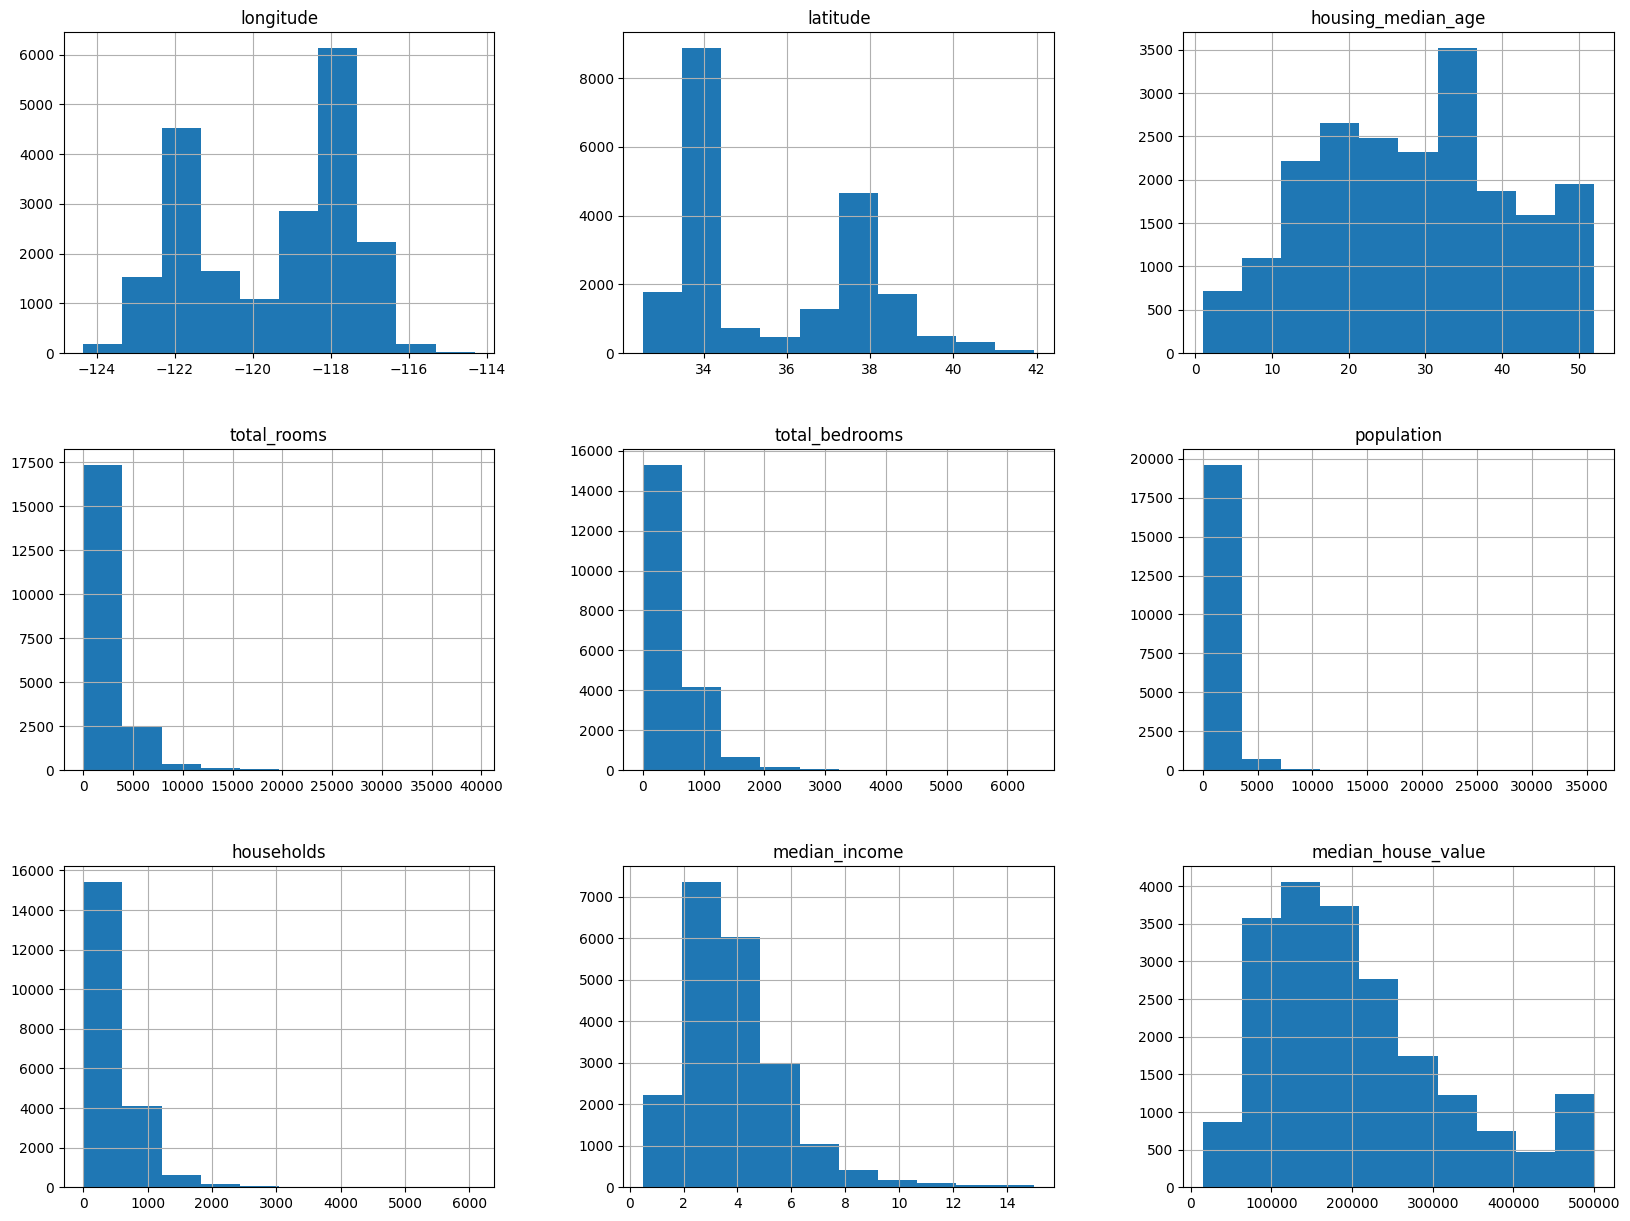

In [17]:
df.hist(bins = 10, figsize = (20,15))
plt.show()

* O atributo renda média não está expresso em dólares (US\$), mas foi dimensionado e limitado em 15 para rendar mais altas e 0.5 para os rendimentos mais baixos. **Obs.1:** É comum trabalhar com atributos pré-processados mas precisamos compreender como foram calculados.
* A idade média e o valor médio de cada imóvel também foram limitados (pode ser um problema sério, por ser o alvo). **Resultado:** O algoritmo pode aprender que os preços nunca passem desse limite. **Ideal:** Conferir com o cliente (que usará as saídas) se isso seria um problema ou não. Caso digam que eles precisam de predições exatas, ainda que ultrapassem US\$ 500 mil, temos 2 opções:
  * Coletar rótulos adequados para as regiões cujos rótulos foram limitados
  * Remover essas regiões do conjunto.
* Esses atributos têm escalas diferentes. Vimos que podemos ter problemas para alguns algoritmos.
* Muitos histogramas tem calda longa, o que tende a estender mais à direita da média do que à esquerda, podendo dificultar a detecção de padrões em alguns algoritmos.

### Separando em treino e teste

O que eu quero prever? Valor das casas

- Qual vai ser o meu y? median_house_value
- Quais variáveis são o X? O resto

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [19]:
#Definir as features e o target
y = df['median_house_value']
X = df.drop(columns='median_house_value')

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   ocean_proximity     20433 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.6+ MB


In [22]:
from sklearn.model_selection import train_test_split

In [41]:
df['ocean_proximity'].value_counts(normalize=True)

,proportion
ocean_proximity,
<1H OCEAN,0.442128
INLAND,0.317917
NEAR OCEAN,0.128615
NEAR BAY,0.111095
ISLAND,0.000245


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25,
                                                    random_state=10, stratify=X['ocean_proximity']) #Estratificada em relação a variável ocean_proximity

Aqui, consideramos apenas uma amostragem aleatória dos dados. Via de regra, isso é bom, caso o conjunto de dados seja grande o suficiente (especialmente em relação ao número de atributos), mas, se não form, podemos correr o risco de introduzir viés de amostragem.

In [44]:
X_train['ocean_proximity'].value_counts(normalize=True)

,proportion
ocean_proximity,
<1H OCEAN,0.442117
INLAND,0.317933
NEAR OCEAN,0.128622
NEAR BAY,0.111068
ISLAND,0.000261


In [45]:
X_test['ocean_proximity'].value_counts(normalize=True)

,proportion
ocean_proximity,
<1H OCEAN,0.442161
INLAND,0.317870
NEAR OCEAN,0.128597
NEAR BAY,0.111176
ISLAND,0.000196


In [36]:
y_train

,median_house_value
4919,105800.0
3791,250000.0
4627,166700.0
35,97200.0
13322,90500.0
...,...
13246,226800.0
19844,52500.0
9944,130400.0
10908,165300.0


No nosso problema, nós pegamos uma amostra em que todos os valores de *total_bedrooms* vieram para os dados de teste.

**Como solucionar?**

Vamos supor que em uma conversa com os especialistas, descobrimos que a renda média é um atributo muito importante para estimar os preços médios. Queremos então, assegurar que o conjunto de testes represente as diversas categorias de rendimentos em todo o conjunto.

Como a renda é um atributo numérico contínuo, primeiro, precisamos criar um atributo categórico para a renda.

Vamos avaliar o histograma dessa variável:

In [37]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [39]:
X_train['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,6782
INLAND,4852
NEAR OCEAN,1974
NEAR BAY,1713
ISLAND,3


In [40]:
X_test['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,2252
INLAND,1644
NEAR OCEAN,654
NEAR BAY,557
ISLAND,2


### Análise e exploração dos dados

#### Visualizando dados geográficos

Como temos informações de latitude e longitude, é uma boa ideia criar um diagrama de dispersão para visualizar os dados de todas as regiões:

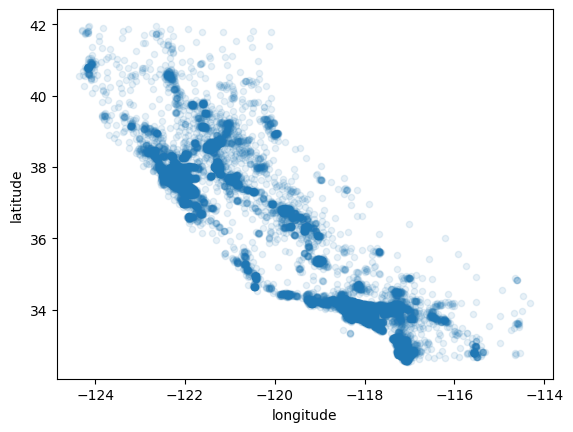

In [47]:
df.plot(kind='scatter', x = 'longitude', y = 'latitude', alpha = .1)
plt.show()

E se a gente quiser comparar isso com os preços dos imóveis.

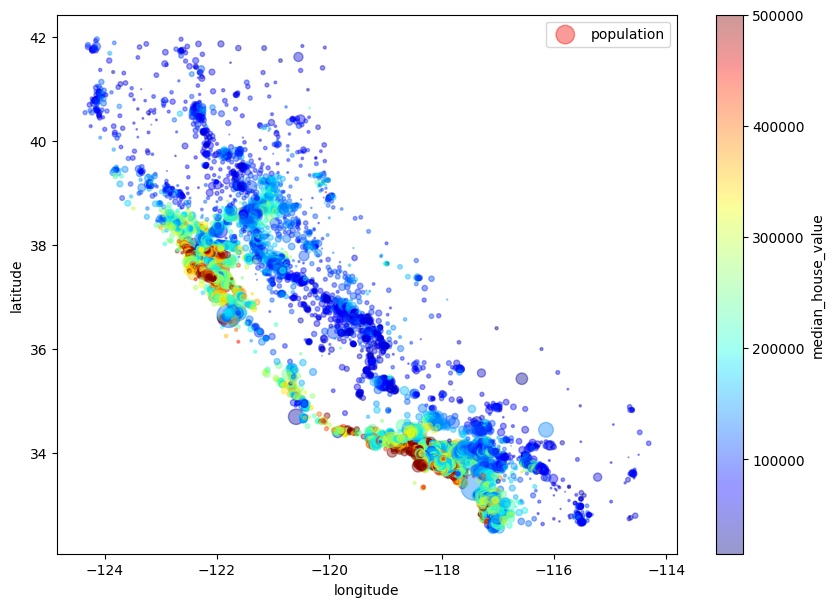

In [51]:
df.plot(kind='scatter', x = 'longitude', y = 'latitude', alpha = .4,
        s = df['population'] / 100, label = 'population', figsize=(10,7),
        c = 'median_house_value', cmap = plt.get_cmap('jet'), colorbar = True)
plt.show()

O que a imagem informa?

* Preços estão relacionados à localização (próximo ao mar) e à densidade populacional.
* **Obs.1:** Um algoritmo de clustering ajudaria muito a detectar o agrupamento principal e adicionar características novas que calculam a proximidade dos centros do cluster.
* A proximidade com o mar também pode ser útil, embora no norte os preços não sejam tão altos, logo não é uma regra simples.

#### Buscando correlações

Podemos avaliar a correlação entre as variáveis, usando corr():

In [52]:
#Selecionar as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['number'])

In [53]:
matriz_correl = colunas_numericas.corr()

In [57]:
matriz_correl['median_house_value'].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688355
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
population,-0.025300
longitude,-0.045398
latitude,-0.144638


* Próximo de 1: forte correlação positiva (valor médio costuma subir quando a renda aumenta).
* Próximo de -1: forte correlação negativa;
* **obs.1:** É possível ver uma pequena correlação negativa com a latitude.
* Próximos de 0: sem correlação linear.

**Importante:**

Com o coeficiente linear, conseguimos apenas notar as correlações lineares e perdemos completamente as correlações não-lineares.

Uma outra forma de observar essas correlações é usar a função scatter_matrix do pandas, plotando cada atributo numérico em relação a outro numérico.

**Obs.1:** Como existem 11 atributos numéricos, obteríamos 112 = 121 plotagens, não cabendo em uma página e por isso, focaremos em alguns promissores com relação ao valor médio.

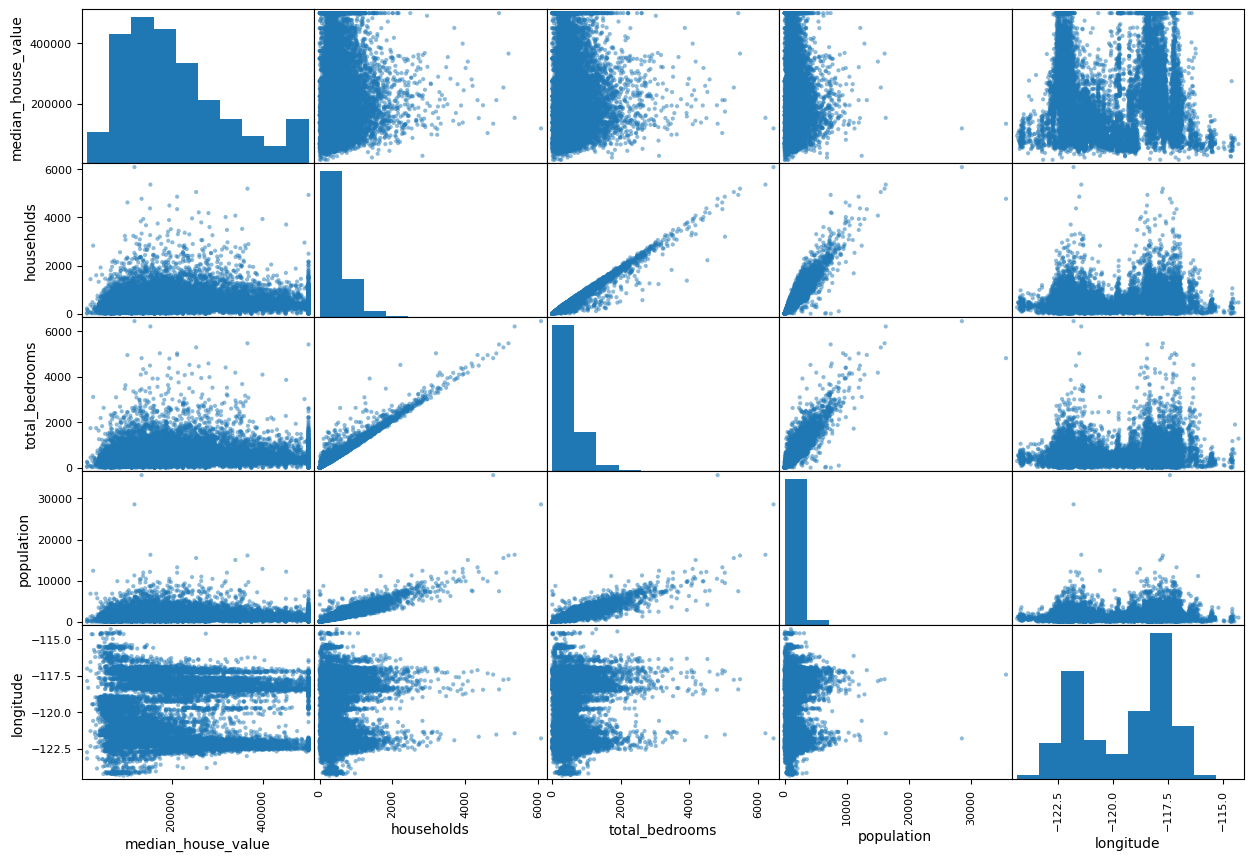

In [59]:
from pandas.plotting import scatter_matrix
atributos = ['median_house_value', 'households', 'total_bedrooms', 'population', 'longitude']
scatter_matrix(df[atributos], figsize = (15,10))
plt.show()

* O pandas plota o histograma na diagonal principal.
* O mais promissor ainda é a renda, com correlação realmente forte.

#### Testando combinações de atributo (Engenharia de Features)

Vimos algumas peculiaridades dos dados, correlações, que existem caldas longas. Com isso, poderíamos por exemplo, transformar em um logaritmo.

Obviamente que a linha de atuação depende de cada projeto, mas há muitas ideias para abordar.

Podemos querer combinações de atributos:
* número de cômodos em uma região não servirá de muita coisa se não soubermos quantas famílias vivem na região. O que quero é o n° de cômodos por família.
* O número de quartos propriamente dito não ajuda muito e provavelmente podemos querer compará-lo com o número de cômodos.
* Ao que tudo indica, a população por domicílio também é uma combinação interessante.

Vamos criar esses novos atributos:

In [60]:
df['rooms_per_household'] = df['total_rooms']/df['households']
df['bedrooms_per_room'] = df['total_bedrooms']/df['total_rooms']
df['population_per_house_hold'] = df['population']/df['households']

In [61]:
colunas_numericas = df.select_dtypes(include=['number'])

In [62]:
matriz_correl = colunas_numericas.corr()

In [64]:
matriz_correl['median_house_value'].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688355
rooms_per_household,0.151344
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
population_per_house_hold,-0.023639
population,-0.025300
longitude,-0.045398


* *bedrooms_per_room* está mais correlacionado com o valor médio do que o n° quartos ou cômodos. Aparentemente, moradias com uma baixa relação quarto/cômodo, tendem a ser mais caras.
* n° cômodo/família também é mais informativo do que total de cômodos em uma região. Obviamente, quanto maior a casa, mais cara.
* **Importante:** A ideia aqui é entender os princípios básicos e obter informações úteis que nos ajudam no modelo.

**Obs.1:** Podemos olhar métricas de cálculo de importância para as variáveis (ex.: feature_importance_ do RandomForest ou SHAP do XGBoost).

## Preparando os dados para os modelos de Aprendizado de Máquina

A etapa posterior é a preparação dos dados para os modelos e para isso, vamos usar os métodos das bibliotecas do Python.

### Limpando os dados

Os modelos de ML não funcionam com características ausentes; sendo assim, usaremos algumas funções para isso.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   longitude                  20433 non-null  float64
 1   latitude                   20433 non-null  float64
 2   housing_median_age         20433 non-null  float64
 3   total_rooms                20433 non-null  float64
 4   total_bedrooms             20433 non-null  float64
 5   population                 20433 non-null  float64
 6   households                 20433 non-null  float64
 7   median_income              20433 non-null  float64
 8   median_house_value         20433 non-null  float64
 9   ocean_proximity            20433 non-null  object 
 10  rooms_per_household        20433 non-null  float64
 11  bedrooms_per_room          20433 non-null  float64
 12  population_per_house_hold  20433 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.2+ MB


Vimos que faltavam alguns valores do atributo total_bedrooms e vamos dar um jeito nisso. Temos 3 opções:
* Abrir mão das regiões correspondentes
* Abrir mão do atributo
* Definir valores para o atributo (média, zero, mediana, etc.).

O sklearn tem uma classe útil para isso, o SimpleImputer.

In [66]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5026,-118.33,33.99,43.0,2224.0,550.0,1598.0,545.0,2.8274,<1H OCEAN
13445,-117.45,34.07,21.0,3465.0,639.0,2292.0,628.0,3.3553,INLAND
20163,-119.31,34.44,5.0,403.0,48.0,208.0,54.0,12.6320,NEAR OCEAN
1423,-122.05,38.00,16.0,1085.0,217.0,356.0,232.0,2.3462,NEAR BAY
2825,-119.09,35.41,12.0,3449.0,522.0,1754.0,551.0,5.6235,INLAND
...,...,...,...,...,...,...,...,...,...
7048,-118.05,33.94,34.0,495.0,120.0,527.0,130.0,1.9453,<1H OCEAN
19352,-122.95,38.73,37.0,1548.0,328.0,863.0,287.0,2.9792,<1H OCEAN
15936,-122.42,37.73,48.0,1474.0,308.0,998.0,330.0,4.0781,NEAR BAY
900,-121.97,37.53,35.0,2277.0,420.0,1353.0,413.0,4.7500,<1H OCEAN


In [67]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
3710,-118.38,34.20,32.0,993.0,285.0,1044.0,248.0,2.4306,<1H OCEAN
4254,-118.35,34.10,16.0,2930.0,1038.0,1648.0,980.0,2.6458,<1H OCEAN
16356,-121.32,38.02,26.0,2851.0,533.0,1544.0,499.0,3.5379,INLAND
6170,-117.92,34.08,36.0,1285.0,228.0,679.0,231.0,3.8705,<1H OCEAN
13217,-117.72,34.00,15.0,4363.0,690.0,2410.0,666.0,5.4824,INLAND
...,...,...,...,...,...,...,...,...,...
18511,-122.00,36.98,43.0,1636.0,324.0,792.0,325.0,3.5562,NEAR OCEAN
8547,-118.35,33.88,36.0,1583.0,411.0,1097.0,350.0,4.0737,<1H OCEAN
10296,-117.87,33.92,14.0,4039.0,669.0,1905.0,670.0,6.3303,<1H OCEAN
11810,-121.07,38.92,15.0,5301.0,884.0,2335.0,831.0,4.5150,INLAND


In [69]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.1 MB/s eta 0:00:00


In [70]:
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [78]:
from category_encoders import OneHotEncoder, TargetEncoder

In [72]:
from sklearn.model_selection import StratifiedKFold

In [73]:
#Instanciar os meus StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [74]:
#Obter as colunas numéricas e categóricas
colunas_categoricas = X_train.select_dtypes('object').columns.to_list()

In [75]:
colunas_numericas = X_train.select_dtypes('number').columns.to_list()

In [76]:
colunas_categoricas

['ocean_proximity']

In [80]:
X_train[colunas_categoricas].value_counts()

,count
ocean_proximity,
<1H OCEAN,6775
INLAND,4872
NEAR OCEAN,1971
NEAR BAY,1702
ISLAND,4


In [77]:
colunas_numericas

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [81]:
#Definindos os pipelines
pipe_cat = Pipeline(
    [
        ('encoder', TargetEncoder())
    ]
)

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy = "median")),
    ('scaler', MinMaxScaler())
])

In [82]:
#Definir o pré-processamento
preprocessing = ColumnTransformer([
    ('categoricas', pipe_cat, colunas_categoricas),
    ('numericas', pipe_num, colunas_numericas)
])

In [83]:
from sklearn.ensemble import RandomForestRegressor

In [94]:
pipe_final = Pipeline([
    ('preprocessamento', preprocessing),
    ('modelo', RandomForestRegressor())
])

In [85]:
pipe_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  Pipeline(steps=[('encoder',
                                                                   TargetEncoder())]),
                                                  ['ocean_proximity']),
                                                 ('numericas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income'])])),
                ('modelo', RandomForestRegressor(max_depth=5))])

In [86]:
y_pred = pipe_final.predict(X_test)

In [87]:
from sklearn.metrics import root_mean_squared_error as rmse, r2_score

In [88]:
rmse(y_test, y_pred)

68323.09543647521

In [89]:
r2_score(y_test, y_pred)

0.6461039142309073

**Significado:** Em média o meu modelo erra o valor da casa em 68323 dólares.

## *ColumnTransformer*


Ele é uma classe da biblioteca sklearn que permite aplicar seletivamente transformações de preparação dos dados.


**Ex.:** Podemos aplicar uma transformação ou sequência de transformações específica apenas às colunas numéricas e uma sequência separada para as colunas categóricas.


**Como usar?** Precisamos especificar uma lista de transformações.
Cada transformador é uma tupla de 3 elementos: (nome do transformador, a transformação, os índices das colunas aplicadas):


$ (Nome, Objeto, Colunas)$

## Otimização de hiperparâmetros

Agora que entendemos como o ***KNN*** funciona e, além disso, aprendemos mais uma ferramenta para facilitar o nosso trabalho, podemos nos aprofundar mais na escolha dos **hiperparâmetros** desse algoritmo.

Até o momento mexemos pouco com **hiperparâmetros** e temos usado praticamente todos eles com as configurações padrão.

**Mas, o que são hiperparâmetros?**

As principais técnicas de otimização são:

> `GridSearchCV`
>
> `RandomizedSearchCV`

## GridSearch

O [Gridsearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) é uma estrutura que o ***sklearn*** proporciona para que seja feita **a busca exaustiva de hiperparâmetros de um estimador**.

Na prática, o que o gridsearch faz é **treinar diversos modelos com diferentes combinações de hiperparâmetros**, de modo a manter o melhor deles como o modelo final, tudo automaticamente!

Tudo o que precisamos fazer é indicar quais os hiperparâmetros que queremos procurar: a **grade**!

<img src="https://www.yourdatateacher.com/wp-content/uploads/2021/03/image-6.png" width=500>

É muito comum também passarmos o **Pipeline** como argumento do gridsearch!

Para maiores informações, [clique aqui](https://scikit-learn.org/stable/modules/grid_search.html#grid-search).

Vamos ver a seguir como esta estrutura funciona:

O Gridsearch avalia o melhor modelo segundo a métrica que passamos em `scoring`. [Clique aqui](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) para ver as métricas disponíveis por padrão.

Mas o GS vai além: ele não calcula a métrica uma única vez, mas sim **várias vezes**, conforme especificado pelo parâmetro `cv`. No fim, o melhor modelo é o que tem o melhor scoring **médio** entre as vezes que é calculado.

O "cv" quer dizer **Cross Validation**, o método mais seguro de realizar um treinamento e avaliação de um modelo que conhecemos na aula passada!

<img src="https://ethen8181.github.io/machine-learning/model_selection/img/kfolds.png" width=600>

Com a validação cruzada, garantimos uma avaliação justa de cada um dos modelos candidatos (cada um construído com uma combinação diferente de hiperparâmetros).

Assim, sabemos que a melhor combinação de hiperparâmetros a ser encontrada não estará de qualquer forma "overfitada" em particularidades da base de treino!

**Desvantagem** do ***GridSearchCV***:

Como a ferramenta testa **TODAS** as possibilidades, caso se deseje testar muitos hiperparâmetros haverão muitas possibilidades, o que é muito demorado! Portanto, temos que tentar outra abordagem.

## ***RandomizedSearchCV***

Uma outra forma de buscar por hiperparâmetros é através **de uma busca aleatória**, o que pode ser feito através do [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

<img src="https://www.yourdatateacher.com/wp-content/uploads/2021/03/image-7.png" width=400>

A diferença entre este buscador e o GridSearch, é que neste caso não explicitamos a lista com os valores dos hiperparâmetros a serem combinados, mas passamos **os valores possíveis dos hiperparâmetros, que são amostrados aleatoriamente de modo a gerar combinações aleatórias!**

Aí, ao invés de tentarmos todas as combinações possíveis, testamos apenas **um número determinado de combinações aleatoriamente amostradas das distribuições!**

<img src=https://miro.medium.com/max/1004/0*yDmmJmvRowl0cSN8.png width=700>

Para mais informações sobre este método, [clique aqui!](https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-search).

[Veja aqui](https://scikit-learn.org/stable/auto_examples/model_selection/plot_randomized_search.html) uma comparação entre os dois métodos.

Em algumas situações, pode ser que a busca aleatória seja mais eficiente que o grid search, dado seu caráter aleatório!

In [90]:
from sklearn.model_selection import RandomizedSearchCV

In [98]:
distributions = {'modelo__max_depth':[1,3,5,7],
                  'modelo__n_estimators':[100, 200,300,400]}

In [104]:
clf = RandomizedSearchCV(pipe_final, distributions, random_state=0, n_iter=2)

In [105]:
search = clf.fit(X_train, y_train)

In [106]:
search.best_params_

{'modelo__n_estimators': 300, 'modelo__max_depth': 3}

In [107]:
search.best_score_

np.float64(0.5827529532121657)